In [1]:
from IPython.display import display, HTML

display(HTML("""
<style>

/* =========================
   전체 레이아웃
========================= */

div.container{
    width:85% !important;
}

div.cell.code_cell.rendered{
    width:100%;
}

div.input_prompt{
    padding:0;
}

div.prompt{
    min-width:70px;
}

div#toc-wrapper{
    padding-top:120px;
}

table.dataframe{
    font-size:12px;
}

/* =========================
   코드 입력창
========================= */

div.CodeMirror{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
    line-height:1.6;
}

/* =========================
   입력 셀
========================= */

div.input{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   코드 출력
========================= */

div.output{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   Markdown 전체
========================= */

.rendered_html{
    font-family:"마루 부리OTF 중간" !important;
    font-size:18px !important;
    line-height:1.8;
}

/* 제목 */
.rendered_html h1,
.rendered_html h2,
.rendered_html h3,
.rendered_html h4,
.rendered_html h5,
.rendered_html h6{
    font-family:"마루 부리OTF 조금굵은" !important;
}

/* 본문 */
.rendered_html p{
    font-family:"마루 부리OTF 중간" !important;
}

/* 리스트 */
.rendered_html li{
    font-family:"마루 부리OTF 중간" !important;
    padding:5px;
}

/* 인용 */
.rendered_html blockquote{
    font-family:"마루 부리OTF 중간" !important;
}

/* 표 */
.rendered_html table{
    font-family:"마루 부리OTF 중간" !important;
}

/* 코드 블록 */
.rendered_html pre,
.rendered_html code{
    font-family:"Consolas" !important;
    font-size:12pt !important;
}

</style>
"""))

In [2]:
import pandas as pd
import numpy as np
from tensorflow.keras import utils # utils.to_categorical()
from tensorflow.keras.models import Sequential # 모델 생성
from tensorflow.keras.layers import Dense, Input
import matplotlib.pyplot as plt

# 로직스틱회귀분석(이진분류)
## 1. 데이터 셋 생성 및 전처리

In [3]:
# 1. csv파일을 데이터프레임을 읽어오기(결측치처리, 타겟변수 균형확인) => 넘파이 배열로 변환 => 데이터 분할
df = pd.read_csv('data/pima-indians-diabetes.csv', comment='#', header=None)
# 1. 임신횟수
# 2. 2시간내 포도당 농도
# 3. 혈압
# 4. 피부접힘 두께
# 5. 인슐린수치
# 6. BMI체질량지수
# 7. 가족력
# 8. 나이
# 9. 당뇨병발병여부
df.sample()

,0,1,2,3,4,5,6,7,8
151,4,114,65,0,0,21.9,0.432,37,0


In [4]:
df.shape

(768, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       768 non-null    int64  
 1   1       768 non-null    int64  
 2   2       768 non-null    int64  
 3   3       768 non-null    int64  
 4   4       768 non-null    int64  
 5   5       768 non-null    float64
 6   6       768 non-null    float64
 7   7       768 non-null    int64  
 8   8       768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.isna().sum() # 열별 결측치 개수

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
dtype: int64

In [7]:
# 타겟변수의 균형 확인
df[8].value_counts()/len(df)

0    0.651042
1    0.348958
Name: 8, dtype: float64

In [8]:
# np.array(df)
dataset = df.values
dataset = df.to_numpy()

In [9]:
# 2. csv파일을 넘파이배열 읽어오기 => 데이터 분할
    # np.loadtxt()
dataset = np.loadtxt('data/pima-indians-diabetes.csv', encoding='utf-8', delimiter=',', ) # comments='#'
dataset.shape

(768, 9)

In [10]:
# 데이터 분할
X_train = dataset[:620, :-1]
y_train = dataset[:620, -1]
X_test = dataset[620:, :-1]
y_test = dataset[620:, -1]
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((620, 8), (620,), (148, 8), (148,))

# 2. 모델 구성

In [11]:
model = Sequential()
# model.add(Dense(64, input_shape=(8,), activation='relu'))
model.add(Input(shape=(8,)) )
model.add(Dense(units=64, activation='relu'))
model.add(Dense(units=32, activation='elu') )
model.add(Dense(units=16, activation='relu') )
model.add(Dense(units=1, activation='sigmoid') ) # 이진분류(로지스틱회귀분석)의 출력층 활성화함수
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                576       
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 16)                528       
                                                                 
 dense_3 (Dense)             (None, 1)                 17        
                                                                 
Total params: 3,201
Trainable params: 3,201
Non-trainable params: 0
_________________________________________________________________


# 3. 학습과정 설정

In [12]:
# model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['binary_accuracy'])
# accuracy가 자동적으로 binary_accuracy 적용
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# 4. 학습

In [13]:
%%time
hist = model.fit(X_train, y_train, # 훈련(학습)데이터셋
                epochs=200, batch_size=310, # validation_data=(X_val, y_val) 검증데이터셋
                validation_split=0.1, # 검증데이터비율(훈련데이터셋에서 10%는 검증데이터셋으로)
                verbose=0 ) # 학습과정 로그 출력 안함.

CPU times: total: 9.56 s
Wall time: 8.49 s


# 5. 모델 평가하기
- 학습과정 시각화하여 살펴보기
- 평가(시험데이터셋)
- 교차표(혼돈매트릭스, 성능평가지표) 그리기

In [14]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

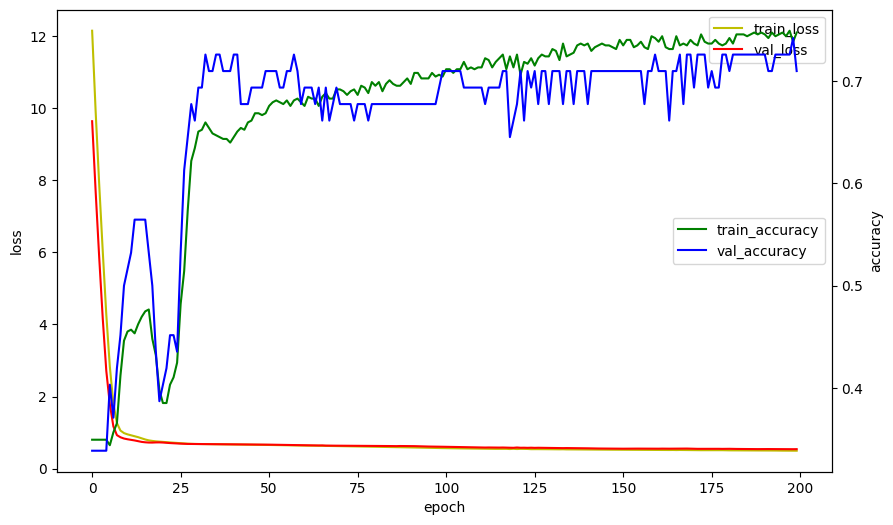

In [15]:
fig, loss_ax = plt.subplots(figsize=(10,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')

acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')

loss_ax.legend()
acc_ax.legend(loc='center right')
plt.show()

In [16]:
# 모델 평가(X)
model.evaluate(X_train, y_train, ) # batch_size=310

20/20 [==============================] - 0s 2ms/step - loss: 0.5034 - accuracy: 0.7403


[0.5033668279647827, 0.7403225898742676]

In [19]:
# 모델 평가(O)
loss, accuracy = model.evaluate(X_test, y_test)
print(f'정확도 : {accuracy*100:.2f}%')

5/5 [==============================] - 0s 2ms/step - loss: 0.6035 - accuracy: 0.6554
정확도 : 65.54%


In [25]:
# 교차표(혼동행렬, 성능평가지표)
y_hat = (model.predict(X_test)>0.5).astype(int)
# y_test : 1차원
# y_hat : 2차원

5/5 [==============================] - 0s 2ms/step


In [28]:
TN=0; FP=0; FN=0; TP=0;
for y, h in zip(y_test, y_hat.reshape(-1)):
#    print(y, h)
    if y==0 and h==0:
        TN += 1
    elif y==0 and h==1:
        FP += 1
    elif y==1 and h==0:
        FN += 1
    else:
        TP += 1
print(TN, FP)
print(FN, TP)

84 12
39 13


In [29]:
y_test.shape

(148,)

In [34]:
ctab = pd.crosstab(y_test.astype(int), # 실제값
               y_hat.reshape(-1))

ctab.index.name = '실제값'
ctab.columns.name = '예측값'
pd.crosstab(y_test.astype(int),
           y_hat.reshape(-1),
            rownames=['실제값'],
            colnames=['예측값'] ) # 결과가 데이터프레임인 교차표

예측값,0,1
실제값,,
0,84,12
1,39,13


In [35]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_hat) # 결과가 numpy배열인 혼동행렬

array([[84, 12],
       [39, 13]], dtype=int64)

In [36]:
precision = 26 / (15+26)
recall = 26 / (26+26)
print('recall :', recall)
print('precision :', precision)

recall : 0.5
precision : 0.6341463414634146


# 6. 모델 사용(예측, 저장)

In [38]:
# 모델 저장
from tensorflow.keras.models import save_model, load_model
model.save('model/05_pima.h5')

In [39]:
# 저장한 모델 Load
model2 = load_model('model/05_pima.h5')

In [40]:
X_test[0]

array([  2.   , 112.   ,  86.   ,  42.   , 160.   ,  38.4  ,   0.246,
        28.   ])

In [50]:
# 예측하기
(model.predict( [[2,112,86,42,160,38.4,0.246,28]] )>0.5).astype(int)

1/1 [==============================] - 0s 37ms/step


array([[0]])

In [ ]:
(model.predict( [[2,112,86,42,160,38.4,0.246,28],
              [] ]) )

# 분류분석
- 1. 데이터 생성 및 전처리 : 훈련셋600, 검증셋100, 테스트셋68로 분리. 타겟변수의 원핫인코딩
- 2. 모델 생성(input8, output2) - 출력층의 활성화함수 softmax
- 3. 모델학습과정 loss='categorical_crossentropy' metrics=['accuracy']
- 4. 모델학습 validation_data = (X_val, y_val)
- 5. 모델학습평가
- 6. 모델사용
    model.predict(input_data).argmax()

## 1. 데이터셋 생성 및 전처리

In [51]:
df = pd.read_csv('data/pima-indians-diabetes.csv', comment='#', header=None)
dataset = df.values

In [52]:
# 훈련셋 600, 검증셋 100, 테스트셋 68
X_train = dataset[:600, :-1]
y_train = dataset[:600, -1]
X_val = dataset[600:700, :-1]
y_val = dataset[600:700, -1]
X_test = dataset[700:, :-1]
y_test = dataset[700:, -1]
X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((600, 8), (600,), (100, 8), (100,), (68, 8), (68,))

In [57]:
# 원핫인코딩 ( 0 : 1 0 / 1: 0 1)
Y_train = utils.to_categorical(y_train, num_classes=2) # pd.get_dummies(y_train)
Y_val = utils.to_categorical(y_val, 2)
Y_test = utils.to_categorical(y_test)
X_train.shape, Y_train.shape, X_val.shape, Y_val.shape, X_test.shape, Y_test.shape

((600, 8), (600, 2), (100, 8), (100, 2), (68, 8), (68, 2))

In [58]:
print('원데이터 :', y_train[:3])
print('원핫인코딩 데이터 :\n', Y_train[:3] )

원데이터 : [1. 0. 1.]
원핫인코딩 데이터 :
 [[0. 1.]
 [1. 0.]
 [0. 1.]]


## 2. 모델생성(input8 -> target2)

In [59]:
model = Sequential()
model.add(Input(shape=(8,)))
model.add(Dense(units=32, activation='relu') ) # 활성화함수 : relu, elu, tanh, sigmoid, softmax
model.add(Dense(units=64, activation='elu') )
model.add(Dense(units=16, activation='relu') )
model.add(Dense(units=2, activation='softmax') ) # 분류분석의 출력층 활성화 함수
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 32)                288       
                                                                 
 dense_5 (Dense)             (None, 64)                2112      
                                                                 
 dense_6 (Dense)             (None, 16)                1040      
                                                                 
 dense_7 (Dense)             (None, 2)                 34        
                                                                 
Total params: 3,474
Trainable params: 3,474
Non-trainable params: 0
_________________________________________________________________


## 3. 학습과정 설정

In [61]:
model.compile(loss='categorical_crossentropy',
             optimizer='nadam',
             metrics=['accuracy'] )

## 4. 모델학습

In [62]:
hist = model.fit(X_train, Y_train,
                epochs=200,
                validation_data=(X_val, Y_val),
                verbose=1)

Epoch 1/200
19/19 [==============================] - 2s 16ms/step - loss: 3.7287 - accuracy: 0.5317 - val_loss: 1.5825 - val_accuracy: 0.4600
Epoch 2/200
19/19 [==============================] - 0s 4ms/step - loss: 1.7122 - accuracy: 0.5483 - val_loss: 1.8269 - val_accuracy: 0.5800
Epoch 3/200
19/19 [==============================] - 0s 3ms/step - loss: 1.3368 - accuracy: 0.6083 - val_loss: 1.8647 - val_accuracy: 0.5000
Epoch 4/200
19/19 [==============================] - 0s 4ms/step - loss: 1.0849 - accuracy: 0.6400 - val_loss: 0.8610 - val_accuracy: 0.6200
Epoch 5/200
19/19 [==============================] - 0s 4ms/step - loss: 1.0411 - accuracy: 0.6000 - val_loss: 1.0324 - val_accuracy: 0.6700
Epoch 6/200
19/19 [==============================] - 0s 4ms/step - loss: 0.9887 - accuracy: 0.6450 - val_loss: 0.6118 - val_accuracy: 0.7200
Epoch 7/200
19/19 [==============================] - 0s 4ms/step - loss: 0.8962 - accuracy: 0.6433 - val_loss: 0.7156 - val_accuracy: 0.6800
Epoch 8/200


Epoch 59/200
19/19 [==============================] - 0s 4ms/step - loss: 0.4797 - accuracy: 0.7733 - val_loss: 0.5653 - val_accuracy: 0.7300
Epoch 60/200
19/19 [==============================] - 0s 3ms/step - loss: 0.5458 - accuracy: 0.7267 - val_loss: 0.5508 - val_accuracy: 0.7200
Epoch 61/200
19/19 [==============================] - 0s 3ms/step - loss: 0.5027 - accuracy: 0.7550 - val_loss: 0.6267 - val_accuracy: 0.6700
Epoch 62/200
19/19 [==============================] - 0s 4ms/step - loss: 0.4781 - accuracy: 0.7583 - val_loss: 0.6928 - val_accuracy: 0.6400
Epoch 63/200
19/19 [==============================] - 0s 3ms/step - loss: 0.5510 - accuracy: 0.7183 - val_loss: 0.5782 - val_accuracy: 0.7500
Epoch 64/200
19/19 [==============================] - 0s 3ms/step - loss: 0.4900 - accuracy: 0.7633 - val_loss: 0.7582 - val_accuracy: 0.7000
Epoch 65/200
19/19 [==============================] - 0s 4ms/step - loss: 0.5649 - accuracy: 0.7217 - val_loss: 0.9063 - val_accuracy: 0.7000
Epoch 

19/19 [==============================] - 0s 5ms/step - loss: 0.4067 - accuracy: 0.8050 - val_loss: 0.6146 - val_accuracy: 0.7000
Epoch 117/200
19/19 [==============================] - 0s 4ms/step - loss: 0.4275 - accuracy: 0.7900 - val_loss: 0.5470 - val_accuracy: 0.7600
Epoch 118/200
19/19 [==============================] - 0s 4ms/step - loss: 0.4340 - accuracy: 0.7917 - val_loss: 0.5482 - val_accuracy: 0.7800
Epoch 119/200
19/19 [==============================] - 0s 4ms/step - loss: 0.4038 - accuracy: 0.8083 - val_loss: 0.5724 - val_accuracy: 0.7700
Epoch 120/200
19/19 [==============================] - 0s 4ms/step - loss: 0.4488 - accuracy: 0.7767 - val_loss: 0.5816 - val_accuracy: 0.7600
Epoch 121/200
19/19 [==============================] - 0s 4ms/step - loss: 0.4293 - accuracy: 0.8017 - val_loss: 0.5885 - val_accuracy: 0.7100
Epoch 122/200
19/19 [==============================] - 0s 4ms/step - loss: 0.4269 - accuracy: 0.7967 - val_loss: 0.5437 - val_accuracy: 0.7300
Epoch 123/200

19/19 [==============================] - 0s 4ms/step - loss: 0.3682 - accuracy: 0.8250 - val_loss: 0.5937 - val_accuracy: 0.7600
Epoch 174/200
19/19 [==============================] - 0s 4ms/step - loss: 0.3806 - accuracy: 0.8233 - val_loss: 0.5810 - val_accuracy: 0.7500
Epoch 175/200
19/19 [==============================] - 0s 3ms/step - loss: 0.3728 - accuracy: 0.8117 - val_loss: 0.6300 - val_accuracy: 0.7200
Epoch 176/200
19/19 [==============================] - 0s 4ms/step - loss: 0.3592 - accuracy: 0.8383 - val_loss: 0.6619 - val_accuracy: 0.7100
Epoch 177/200
19/19 [==============================] - 0s 4ms/step - loss: 0.3559 - accuracy: 0.8350 - val_loss: 0.6473 - val_accuracy: 0.7300
Epoch 178/200
19/19 [==============================] - 0s 4ms/step - loss: 0.3647 - accuracy: 0.8317 - val_loss: 0.6058 - val_accuracy: 0.7300
Epoch 179/200
19/19 [==============================] - 0s 5ms/step - loss: 0.3650 - accuracy: 0.8233 - val_loss: 0.6351 - val_accuracy: 0.7300
Epoch 180/200

## 5. 모델평가

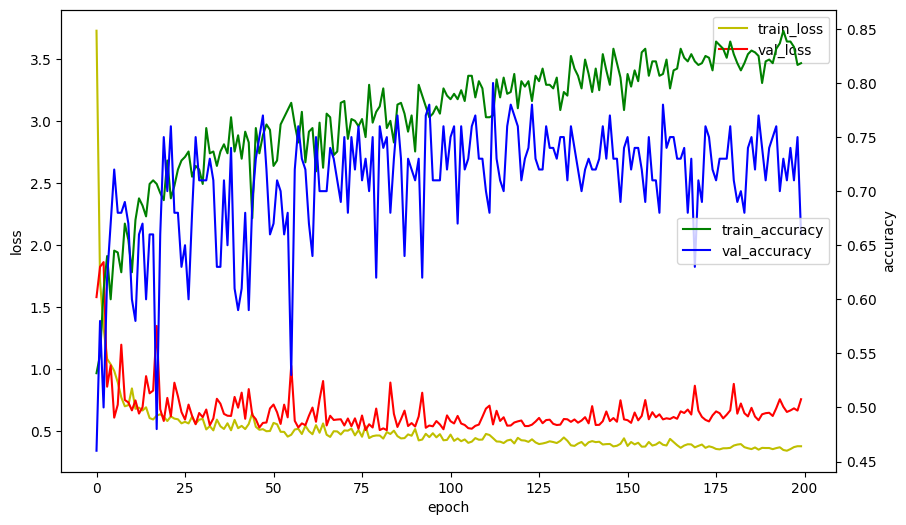

In [63]:
fig, loss_ax = plt.subplots(figsize=(10,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')

acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')

loss_ax.legend()
acc_ax.legend(loc='center right')
plt.show()

In [65]:
# 모델 평가
model.evaluate(X_test, Y_test)
accuracy

3/3 [==============================] - 0s 2ms/step - loss: 0.7267 - accuracy: 0.6912


0.6554054021835327

In [70]:
# 혼동행렬==교차표를 위한 y_test의 예측값
y_hat = model.predict(X_test).argmax(axis=1) # 예측값 / 실제값 y_hat
y_hat.shape, y_test.shape

3/3 [==============================] - 0s 2ms/step


((68,), (68,))

In [72]:
# 교차표(데이터 프레임)
pd.crosstab(y_test, y_hat, rownames=['실제값'], colnames=['예측값'])

예측값,0,1
실제값,,
0.0,27,14
1.0,7,20


In [73]:
# 혼동행렬
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_hat)

array([[27, 14],
       [ 7, 20]], dtype=int64)

## 6. 모델 사용(예측)

In [74]:
X_test[0]

array([  2.   , 122.   ,  76.   ,  27.   , 200.   ,  35.9  ,   0.483,
        26.   ])

In [77]:
model.predict( [[ 2,122,76,27,200,35.9,0.483,26]]).argmax(axis=1)

1/1 [==============================] - 0s 40ms/step


array([0], dtype=int64)